In [169]:
import numpy as np
import matplotlib.pyplot as plt

In [185]:
J = 0.1 * 10**(-3) * 1.60217663 * 10**(-19) #1meV
dt = 1 * 10**(-14) #0.01ps
Time = 5 * 10**(-12) #10ps

hbar = 1.054571817 * 10**(-34)


NSteps = int(Time/dt)

In [187]:
t1 = 1 * 10**(-12) #1ps
g1 = 1/t1
t2 = 1 * 10**(-12) #1ps
g2 = 1/t2

L1 = np.array([
    [0,  1],
    [0, 0]
], dtype=complex)*np.sqrt(g1)

L2 = np.array([
    [1,  0],
    [0, -1]
], dtype=complex)*np.sqrt(g2)


L_list = [L1, L2]

In [189]:
def comutator(A, B):
    return A@B-B@A
def anticomutator(A, B):
    return A@B+B@A
def lindbladOp(L, rho):
    return L @ rho @ np.conj(L.T) - 0.5*anticomutator(np.conj(L.T)@L,rho)
def FixRho(rho):
    # 1. Wymuszenie hermitowskości
    rho = (rho + rho.conj().T) / 2

    # 2. Diagonalizacja
    eigvals, eigvecs = np.linalg.eigh(rho)

    # 3. Naprawa wartości własnych (ujemne → 0)
    eigvals = np.clip(eigvals, 0, None)

    # 4. Rekonstrukcja macierzy
    rho_fixed = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T

    # 5. Normalizacja śladu do 1
    rho_fixed /= np.trace(rho_fixed)

    return rho_fixed
def EvoOp(H, L_list, rho):
    op = -1j/hbar*comutator(H, rho)
    for Li in L_list:
        op += lindbladOp(Li,rho)
    return op
    

In [191]:
H = np.array([
    [1,  1],
    [1, -1]
], dtype=complex)*J

psi0 = np.array([1, 1], dtype=complex)
psi0 /= np.linalg.norm(psi0)

rho0 = np.outer(psi0, np.conj(psi0))

print(rho0)

[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]


In [193]:
rho_prev = rho0.copy()
rho_curr = rho0-1j/hbar*dt*comutator(H,rho0)

rho_curr /= np.trace(rho_curr)

times = [0.0, dt]
states = [rho_prev.copy(), rho_curr.copy()]


for i in range(1, NSteps):
    k1 = EvoOp(H, L_list, rho_curr)
    k2 = EvoOp(H, L_list, rho_curr + dt/2 * k1)
    k3 = EvoOp(H, L_list, rho_curr + dt/2 * k2)
    k4 = EvoOp(H, L_list, rho_curr + dt * k3)

    rho_next = rho_curr + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
    

    # normalization (H is hermitian but its discretization might be not!)
    rho_next = FixRho(rho_next)

    rho_prev = rho_curr
    rho_curr = rho_next

    times.append((i + 1) * dt)
    states.append(rho_curr.copy())
times = np.array(times)

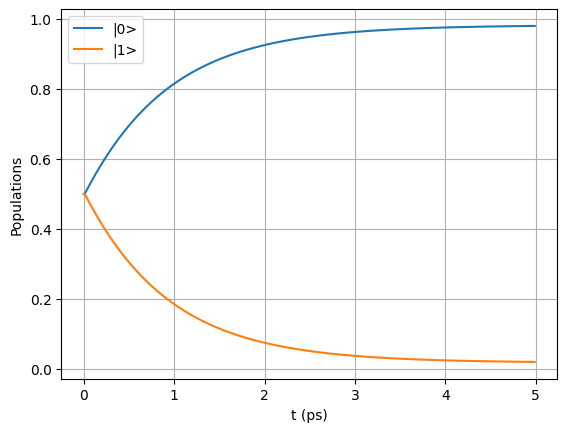

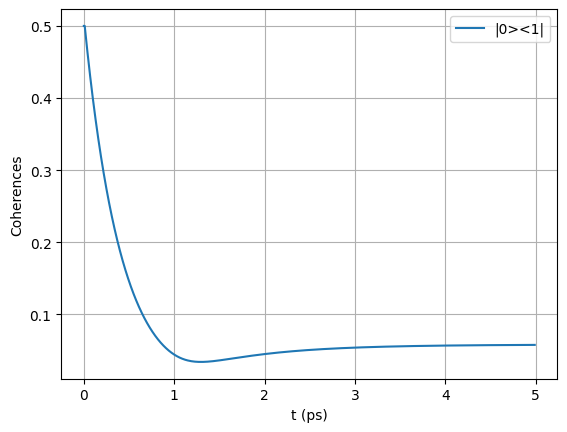

In [194]:
# ----------------------------
# Populations
# ----------------------------
states = np.array(states)
pop_0 = np.abs(states[:, 0, 0])
pop_1 = np.abs(states[:, 1, 1])
coh_01 = np.abs(states[:, 0, 1])

#print(states[NSteps,:,:])
#print(lindbladOp(L1,states[NSteps,:,:]))
#print(states[NSteps-1,:,:])
#print(lindbladOp(L1,states[NSteps-1,:,:]))

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(times*10**(12), pop_0, label='|0>')
ax.plot(times*10**(12), pop_1, label='|1>')
ax.set_xlabel("t (ps)")
ax.set_ylabel("Populations")
ax.legend()
ax.grid(True)
plt.show()

fig, ax = plt.subplots()
ax.plot(times*10**(12), coh_01, label='|0><1|')
ax.set_xlabel("t (ps)")
ax.set_ylabel("Coherences")
ax.legend()
ax.grid(True)
plt.show()

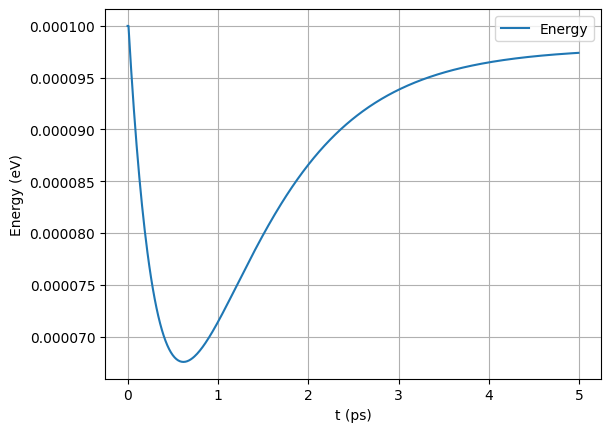

In [197]:
Energies = []
for i in range(0, NSteps+1):
    Energies.append(np.trace(H @ states[i,:,:]).real)

Energies = np.array(Energies)

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots()
ax.plot(times*10**(12), Energies/(1.60217663 * 10**(-19)), label='Energy')
ax.set_xlabel("t (ps)")
ax.set_ylabel("Energy (eV)")
ax.legend()
ax.grid(True)
plt.show()